# 정적 페이지 수집하기

* 순수 HTML, CSS로 만들어진 페이지
* javascript로 내용을 갱신하지 않는 페이지

In [1]:
import requests

In [2]:
# 나라장터
url  = "https://www.g2b.go.kr/"
r = requests.get(url)
r.text

'<!DOCTYPE html PUBLIC "-//W3C//DTD HTML 4.01 Transitional//EN" "http://www.w3.org/TR/html4/loose.dtd">\n<html>\n<head>\n    <meta charset="UTF-8">\n    <meta http-equiv="X-UA-Compatible" content="IE=edge">\n    <meta name="viewport" content="width=device-width, initial-scale=1.0">\n    <title>접근 가능 브라우저 안내</title>\n    <link rel="stylesheet" href="https://www.g2b.go.kr/static/info/css/common.css">\n\n</head>\n<body class="wrapper sys">\n    <div class="conArea">\n        <h1>나라장터 국가종합전자조달</h1>\n        <div class="conBox">\n            <h2>접근 가능 브라우저 안내</h2>\n            <div class="conText">\n                <div>\n                    <p>차세대 나라장터 안정적인 지원을 위해 <span>HTML5를 지원 하는 브라우저로 접근 가능합니다.</span>\n                    <br>크롬, 엣지 브라우저로 접근 부탁 드립니다. </p>\n                </div>\n            </div>\n        </div>\n    </div>\n</body>\n</html>\n'

In [3]:
# yes24
url  = "https://www.yes24.com/product/category/bestseller?CategoryNumber=001&sumgb=06"
r = requests.get(url)
r = r.content

In [ ]:
soup = bs(r, 'lxml')
soup

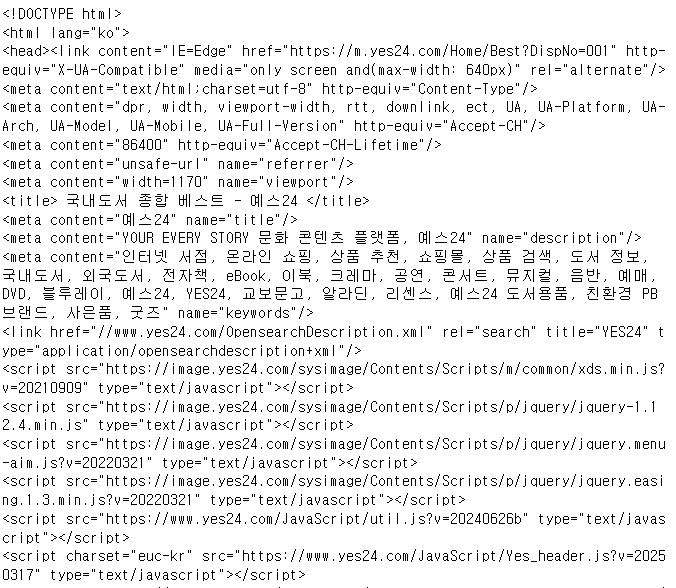

개발자 도구 - select elements - 원하는 요소 커서 - f12 html 태그에서 해당 요소 코드 우클릭 - copy - copy selector

In [ ]:
# yesBestList

In [ ]:
# yesBestList > li:nth-child(1) > div > div.item_info > div.info_row.info_name > a.gd_name

In [5]:
for title in soup.select("a.gd_name"):
    print(title)

<a class="gd_name" href="/product/goods/144021119" onclick="wiseLogV2('BS', '001_005_001', ''); ">단 한 번의 삶</a>
<a class="gd_name" href="/product/goods/145008767" onclick="wiseLogV2('BS', '001_005_001', ''); ">결국 국민이 합니다</a>
<a class="gd_name" href="/product/goods/142876017" onclick="wiseLogV2('BS', '001_005_001', ''); ">듀얼 브레인</a>
<a class="gd_name" href="/product/goods/144958591" onclick="wiseLogV2('BS', '001_005_001', ''); ">사카모토 데이즈 비기너즈 팩 Vol.2</a>
<a class="gd_name" href="/product/goods/142687238" onclick="wiseLogV2('BS', '001_005_001', ''); ">어른의 품격을 채우는 100일 필사 노트</a>
<a class="gd_name" href="/product/goods/116433040" onclick="wiseLogV2('BS', '001_005_001', ''); ">줬으면 그만이지</a>
<a class="gd_name" href="/product/goods/136298166" onclick="wiseLogV2('BS', '001_005_001', ''); ">어른의 행복은 조용하다</a>
<a class="gd_name" href="/product/goods/13137546" onclick="wiseLogV2('BS', '001_005_001', ''); ">소년이 온다</a>
<a class="gd_name" href="/product/goods/8759796" onclick="wiseLogV2('BS', '001_005_0

In [6]:
soup.select("em.yes_b")

[<em class="yes_b">15,120</em>,
 <em class="yes_b">9.0</em>,
 <em class="yes_b">19,800</em>,
 <em class="yes_b">8.7</em>,
 <em class="yes_b">18,900</em>,
 <em class="yes_b">8.2</em>,
 <em class="yes_b">17,550</em>,
 <em class="yes_b">18,000</em>,
 <em class="yes_b">9.9</em>,
 <em class="yes_b">18,000</em>,
 <em class="yes_b">9.9</em>,
 <em class="yes_b">16,020</em>,
 <em class="yes_b">9.5</em>,
 <em class="yes_b">13,500</em>,
 <em class="yes_b">9.7</em>,
 <em class="yes_b">11,700</em>,
 <em class="yes_b">9.6</em>,
 <em class="yes_b">6,930</em>,
 <em class="yes_b">9.8</em>,
 <em class="yes_b">16,020</em>,
 <em class="yes_b">9.5</em>,
 <em class="yes_b">14,850</em>,
 <em class="yes_b">9.7</em>,
 <em class="yes_b">14,220</em>,
 <em class="yes_b">15,120</em>,
 <em class="yes_b">10.0</em>,
 <em class="yes_b">14,400</em>,
 <em class="yes_b">9.6</em>,
 <em class="yes_b">15,120</em>,
 <em class="yes_b">9.6</em>,
 <em class="yes_b">3,510</em>,
 <em class="yes_b">4.3</em>,
 <em class="yes_b">17,

# yes24 베스트셀러 자료 수집하기

In [2]:
import pandas as pd
import requests
import time
from bs4 import BeautifulSoup as bs

lxml 선택 시
* 대용량 데이터 처리
* 빠른 성능 필요
* XPath 사용 필요

xml 선택 시
* 간단한 데이터 처리
* 추가 설치 없이 사용
* 기본 기능만 필요

In [4]:
# url은 "?" 앞까지! 그 뒤는 파라미터
url = "https://www.yes24.com/product/category/bestseller"
payload = dict(CategoryNumber= "001", pageNumber=1, pageSize=120)
r = requests.get(url, params=payload)
print(r.url)
print(r.status_code)
soup = bs(r.content, "lxml")
time.sleep(5)
# soup

https://www.yes24.com/product/category/bestseller?CategoryNumber=001&pageNumber=1&pageSize=120
200


* id를 부모요소로 먼저 잘라오자 (id는 유일한 단일요소임)
* **최우선적으로 찾아와야 하는 것은 id이다.**

* 전체 yes24 베스트셀러 페이지 중 책 정보가 들어있는 곳: ul#yesBestList
* ul#yesBestList 아래의 li에 책 1권의 정보가 들어있음.

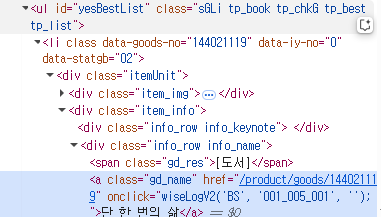

In [14]:
# yes24 전체 페이지에서 책 정보가 들어있는
book_list = soup.select("ul#yesBestList > li")
# book_list

In [19]:
book_list[:2]

[<li class="" data-goods-no="144021119" data-iy-no="0" data-statgb="02">
 <div class="itemUnit">
 <div class="item_img">
 <div class="img_canvas">
 <div class="img_upper">
 <em class="ico rank">1</em>
 <span class="rank_info rank_even">
 <span class="ico"></span><em class="txt rank"></em><em class="txt">위 상승</em>
 </span>
 </div>
 <span class="img_item">
 <span class="img_grp">
 <a class="lnk_img" href="/product/goods/144021119" onclick="wiseLogV2('BS', '001_005_001', ''); ">
 <em class="img_bdr">
 <img alt="단 한 번의 삶" border="0" class="lazy" data-original="https://image.yes24.com/goods/144021119/L" src="https://image.yes24.com/momo/Noimg_L.jpg"/>
 </em>
 </a>
 </span>
 </span>
 </div>
 <div class="img_btn">
 <a class="btnC btn_preview" href="javascript:yes24GU.openPreviewCheck(144021119); wiseLogV2('BS', '001_005_011', '');"><span class="bWrap"><em class="txt">미리보기</em></span></a>
 </div>
 </div>
 <div class="item_info">
 <div class="info_row info_keynote">
 <span class="gd_keynote" id

In [5]:
# 조건 표현식으로 예외처리 (평점 X, 리뷰수 X인 책)
# 웹은 key나 value 변동성이 매우 크다.

book_list = soup.select("ul#yesBestList > li")
result = {}
for idx, book in enumerate (book_list):
    print(f'{idx}/{len(book_list)} 추출중', end="\r")
    # 책 제목
    book_title = book.select_one(".gd_name").text
    # 저자
    author = book.select_one(".info_row.info_pubGrp a").text
    # 출판사
    publisher = book.select_one(".authPub.info_pub a").text
    # 출간일
    data = book.select_one(".authPub.info_date").text
    # 가격
    price = book.select_one(".info_row.info_price em.yes_b").text
    # 평점
    rating = book.select_one(".rating_grade em.yes_b").text if book.select_one(".rating_grade em.yes_b") != None else 0.0
    # 리뷰수
    n_reviews = book.select_one(".info_row.info_rating em.txC_blue").text if book.select_one(".info_row.info_rating em.txC_blue") != None else 0
    
    keys = ['book_title', 'author', 'publisher', 'data', 'price', 'rating', 'n_reviews']
    values = [book_title, author, publisher, data, price, rating, n_reviews]

    for key, value in zip(keys, values):
        result.setdefault(key, []).append(value)
        
# for key, value in result.items():
# #     print(key, len(value))

df = pd.DataFrame(result)
df

,book_title,author,publisher,data,price,rating,n_reviews
0,단 한 번의 삶,김영하,복복서가,2025년 04월,"15,120",9.0,60
1,결국 국민이 합니다,이재명,오마이북,2025년 04월,"19,800",8.5,73
2,듀얼 브레인,이선 몰릭,상상스퀘어,2025년 03월,"18,900",8.3,51
3,줬으면 그만이지,김주완,피플파워,2023년 01월,"18,000",9.9,38
4,사카모토 데이즈 비기너즈 팩 Vol.2,스즈키 유우토,대원,2025년 04월,"17,550",0.0,0
...,...,...,...,...,...,...,...
115,2025 이유진 국어 백일기도 모의고사 [시즌3_結(결)],이유진,고시동네,2025년 02월,"26,100",9.9,35
116,내 인생 최악의 일주일 4 목요일,맷 코스그로브,비룡소,2025년 04월,"12,600",0.0,0
117,생각의 도약,도야마 시게히코,페이지2북스,2025년 01월,"16,200",9.4,57
118,2025 써니 행정법총론 기출문제집,박준철,에스티유니타스,2024년 11월,"39,600",9.9,53


### 조건 표현식 리마인드

In [58]:
x = 3
if x % 2 == 0:
    print("짝수")
else:
    print("홀수")

짝수


In [61]:
x = 3 
print("짝수") if x % 2 == 0 else print("홀수")

홀수


In [6]:
print("가격: ", len(list(soup.select("ul#yesBestList .info_row.info_price em.yes_b"))))

가격:  24


In [20]:
result['author'][29]

'정관 스님'

In [70]:
for author in book_list[20].select(".info_row.info_pubGrp a"):
    print(author.text)

백온유
강보라
서장원
성해나
성혜령
정보 더 보기/감추기
백온유
강보라
서장원
성해나
성혜령
이희주
현호정
문학동네


In [22]:
book_list[29].select_one(".authPub.info_auth").text

'\n정관 스님, 후남 셀만 저/베로니크 회거 사진/양혜영 역\r\n                            '

In [23]:
book_list[29].select_one(".authPub.info_auth").text.split("/")[0]

'\n정관 스님, 후남 셀만 저'

In [17]:
book_list[28].select_one(".authPub.info_auth").text.split("/")[1]

'베로니크 회거 사진'

In [18]:
book_list[28].select_one(".authPub.info_auth").text.split("/")[2]

'양혜영 역\r\n                            '

In [21]:
book_list[20].select_one(".authPub.info_auth").text

'\n백온유, 강보라, 서장원, 성해나, 성혜령 저 외 2명\r\n                                        \n정보 더 보기/감추기\n\n\n\n백온유\n강보라\n서장원\n성해나\n성혜령\n이희주\n현호정\n\n\n\n\n'

### 저자가 많은 경우

In [25]:
book_list[18].select_one(".authPub.info_auth").text.split("/")[1].replace("\n", " ").strip("감추기\n ")

'백온유 강보라 서장원 성해나 성혜령 이희주 현호정'

### 링크

In [ ]:
https://www.yes24.com/product/goods/138282792

In [8]:
link = "https://www.yes24.com" + book_list[20].select_one(".gd_name")['href']

In [10]:
print(link)

https://www.yes24.com/product/goods/142605459


# 전체 페이지 출력하기

In [31]:
import requests
import pandas as pd
import time
from bs4 import BeautifulSoup as bs

In [ ]:
# 도서명, 저자, 출판사, 출간일, 가격, 회원리뷰 점수, 회원리뷰 건수

In [52]:
df_list = []
page=1
while True:
    url = "https://www.yes24.com/product/category/bestseller"
    payload = dict(CategoryNumber= "001", pageNumber=page, pageSize=100)
    r = requests.get(url, params=payload)
    print(r.url, end = "\r")
    print(r.status_code, end = "\r")
    soup = bs(r.content, "lxml")
    time.sleep(5)
    book_list = soup.select("ul#yesBestList > li")
    result = {}
    for idx, book in enumerate (book_list):
        print(f'{idx}/{len(book_list)} 추출중', end="\r")
        # 책 제목
        book_title = book.select_one(".gd_name").text
        # 저자
        author = book.select_one(".info_row.info_pubGrp a").text
        # 출판사
        publisher = book.select_one(".authPub.info_pub a").text
        # 출간일
        data = book.select_one(".authPub.info_date").text
        # 가격
        price = book.select_one(".info_row.info_price em.yes_b").text
        # 평점
        rating = book.select_one(".rating_grade em.yes_b").text if book.select_one(".rating_grade em.yes_b") != None else 0.0
        # 리뷰수
        n_reviews = book.select_one(".info_row.info_rating em.txC_blue").text if book.select_one(".info_row.info_rating em.txC_blue") != None else 0

        keys = ['book_title', 'author', 'publisher', 'data', 'price', 'rating', 'n_reviews']
        values = [book_title, author, publisher, data, price, rating, n_reviews]
        for key, value in zip(keys, values):
            result.setdefault(key, []).append(value)
  
    df_list.append(pd.DataFrame(result))     
    if page < 10:
        page += 1
    else:
        break

#     for key, value in result.items():
#         print(key, len(value))

result_df = pd.concat(df_list)
result_df = result_df.reset_index(drop=True)
result_df

,book_title,author,publisher,data,price,rating,n_reviews
0,단 한 번의 삶,김영하,복복서가,2025년 04월,"15,120",8.9,9
1,듀얼 브레인,이선 몰릭,상상스퀘어,2025년 03월,"18,900",8.7,38
2,어른의 품격을 채우는 100일 필사 노트,김종원,청림Life,2025년 03월,"18,000",9.9,56
3,소년이 온다,한강,창비,2014년 05월,"13,500",9.7,"3,845"
4,성적 초격차를 만드는 독서력 수업,김수미,빅피시,2025년 03월,"17,820",9.9,67
...,...,...,...,...,...,...,...
994,오십의 기술,이호선,카시오페아,2023년 04월,"16,200",9.2,48
995,햇빛초 대나무 숲에 새 글이 올라왔습니다,황지영,우리학교,2020년 08월,"13,050",9.9,68
996,처음 읽는 그리스 로마 신화 2,최설희,미래엔아이세움,2020년 08월,"10,800",9.9,84
997,"칵테일, 러브, 좀비",조예은,안전가옥,2020년 04월,"11,700",9.2,"1,132"


In [ ]:
https://www.yes24.com/product/category/bestseller?categoryNumber=001&pageNumber=42&pageSize=24

In [ ]:
# 도서명, 저자, 사진, 역자, 출판사, 출간일, 가격, 회원리뷰 점수, 회원리뷰 건수

In [56]:
for i in b:
    print(i)

<a href="https://www.yes24.com/product/search?domain=ALL&amp;query=%25ED%2594%25BC%25ED%2584%25B0%2520%25EB%25B8%258C%25EB%259D%25BC%25EC%259A%25B4&amp;authorNo=230215&amp;author=피터 브라운" target="">피터 브라운</a>
<a href="https://www.yes24.com/product/search?domain=ALL&amp;query=%25EC%2597%2584%25ED%2598%259C%25EC%2588%2599&amp;authorNo=125451&amp;author=엄혜숙" target="">엄혜숙</a>
<a href="https://www.yes24.com/product/search?&amp;domain=ALL&amp;company=%ea%b1%b0%eb%b6%81%ec%9d%b4%eb%b6%81%ec%8a%a4&amp;query=%25EA%25B1%25B0%25EB%25B6%2581%25EC%259D%25B4%25EB%25B6%2581%25EC%258A%25A4">거북이북스</a>


In [62]:
soup.select_one(".gd_name").text

'쓰다 보니, 쓸 만해졌습니다'

In [ ]:
df_list = []
page=1
while True:
    url = "https://www.yes24.com/product/category/bestseller"
    payload = dict(CategoryNumber= "001", pageNumber=page, pageSize=100)
    r = requests.get(url, params=payload)
    print(r.url, end = "\r")
    print(r.status_code, end = "\r")
    soup = bs(r.content, "lxml")
    time.sleep(5)
    book_list = soup.select("ul#yesBestList > li")
    result = {}
    for idx, book in enumerate (book_list):
        print(f'{idx}/{len(book_list)} 추출중', end="\r")
        # 책 제목
        book_title = book.select_one(".gd_name").text
        # 저자 (공동저자 모두 나오게끔)
        author = book.select_one(".info_row.info_pubGrp a").text
        # 사진
        
        # 역자
        # 출판사
        publisher = book.select_one(".authPub.info_pub a").text
        # 출간일
        data = book.select_one(".authPub.info_date").text
        # 가격
        price = book.select_one(".info_row.info_price em.yes_b").text
        # 평점
        rating = book.select_one(".rating_grade em.yes_b").text if book.select_one(".rating_grade em.yes_b") != None else 0.0
        # 리뷰수
        n_reviews = book.select_one(".info_row.info_rating em.txC_blue").text if book.select_one(".info_row.info_rating em.txC_blue") != None else 0

        keys = ['book_title', 'author', 'publisher', 'data', 'price', 'rating', 'n_reviews']
        values = [book_title, author, publisher, data, price, rating, n_reviews]
        for key, value in zip(keys, values):
            result.setdefault(key, []).append(value)
  
    df_list.append(pd.DataFrame(result))     
    if page < 10:
        page += 1
    else:
        break

#     for key, value in result.items():
#         print(key, len(value))

result_df = pd.concat(df_list)
result_df = result_df.reset_index(drop=True)
result_df

In [64]:
book_list = soup.select("ul#yesBestList > li")


In [6]:
print("가격: ", len(list(soup.select("ul#yesBestList .info_row.info_price em.yes_b"))))

가격:  24


In [7]:
result['author'][28]

'정관 스님'

In [70]:
# 저자가 여러 명일 경우
for author in book_list[20].select(".info_row.info_pubGrp a"):
    print(author.text)

백온유
강보라
서장원
성해나
성혜령
정보 더 보기/감추기
백온유
강보라
서장원
성해나
성혜령
이희주
현호정
문학동네


In [21]:
book_list[20].select_one(".authPub.info_auth").text

'\n백온유, 강보라, 서장원, 성해나, 성혜령 저 외 2명\r\n                                        \n정보 더 보기/감추기\n\n\n\n백온유\n강보라\n서장원\n성해나\n성혜령\n이희주\n현호정\n\n\n\n\n'

# 저자/사진/역자 풀이

In [ ]:
import pandas as pd
import time
import requests
from bs4 import BeautifulSoup as bs

In [69]:
# 전체 row(베스트셀러 순위) 개수가 999라는 걸 사전에 알고 있기에, for 문으로 해보았다.

result_list = []
for page in range(1, 9):
    url = "https://www.yes24.com/product/category/bestseller"
    payload = dict(CategoryNumber= "001", pageNumber=page, pageSize=120)
    r = requests.get(url, params=payload)
    print(r.url, end = "\r")
    print(r.status_code, end = "\r")
    soup = bs(r.content, "lxml")
    time.sleep(5)
    book_list = soup.select("ul#yesBestList > li")
    result = {}
    for idx, book in enumerate (book_list):
        print(f'{idx}/{len(book_list)} 추출중', end="\r")
        # 책 제목
        book_title = book.select_one(".gd_name").text
        # 저자
        author = book.select_one(".info_row.info_pubGrp a").text
        # 출판사
        publisher = book.select_one(".authPub.info_pub a").text
        # 출간일
        data = book.select_one(".authPub.info_date").text
        # 가격
        price = book.select_one(".info_row.info_price em.yes_b").text
        # 평점
        rating = book.select_one(".rating_grade em.yes_b").text if book.select_one(".rating_grade em.yes_b") != None else 0.0
        # 리뷰수
        n_reviews = book.select_one(".info_row.info_rating em.txC_blue").text if book.select_one(".info_row.info_rating em.txC_blue") != None else 0

        keys = ['book_title', 'author', 'publisher', 'data', 'price', 'rating', 'n_reviews']
        values = [book_title, author, publisher, data, price, rating, n_reviews]
        for key, value in zip(keys, values):
            result.setdefault(key, []).append(value)
  
    
    result_list.append(pd.DataFrame(result))     

#     for key, value in result.items():
#         print(key, len(value))

result_list = pd.concat(result_list)
result_list = result_df.reset_index(drop=True)
result_list

,book_title,author,publisher,data,price,rating,n_reviews
0,단 한 번의 삶,김영하,복복서가,2025년 04월,"15,120",8.9,9
1,듀얼 브레인,이선 몰릭,상상스퀘어,2025년 03월,"18,900",8.7,38
2,어른의 품격을 채우는 100일 필사 노트,김종원,청림Life,2025년 03월,"18,000",9.9,56
3,소년이 온다,한강,창비,2014년 05월,"13,500",9.7,"3,845"
4,성적 초격차를 만드는 독서력 수업,김수미,빅피시,2025년 03월,"17,820",9.9,67
...,...,...,...,...,...,...,...
994,오십의 기술,이호선,카시오페아,2023년 04월,"16,200",9.2,48
995,햇빛초 대나무 숲에 새 글이 올라왔습니다,황지영,우리학교,2020년 08월,"13,050",9.9,68
996,처음 읽는 그리스 로마 신화 2,최설희,미래엔아이세움,2020년 08월,"10,800",9.9,84
997,"칵테일, 러브, 좀비",조예은,안전가옥,2020년 04월,"11,700",9.2,"1,132"


# 저자, 역자, 글그림, 편저, 공동 저자 등 구분하기

In [71]:
url = "https://www.yes24.com/product/category/bestseller"
payload = dict(CategoryNumber= "001", pageNumber=1, pageSize=120)
r = requests.get(url, params=payload)
print(r.url, end = "\r")
print(r.status_code, end = "\r")
soup = bs(r.content, "lxml")
time.sleep(5)
book_list = soup.select("ul#yesBestList > li")

In [13]:
# 줄바꿈, 캐리지 리턴 제거하는 함수

def text_clean(text):
    return text.replace("\n", " ").replace("\r", " ").strip()

In [14]:
# 저자, 역자, 글그림, 편저, 공동 저자 등 구분하는 함수

def author_extraction(book):
    author= ""
    photo = ""
    trans = ""
    paint = ""
    for idx, item in enumerate(text_clean(book.select_one(".authPub.info_auth").text).split("/")):
        print(idx,item)
        if idx == 0:
            if "저" == item[-1]:
                author = text_clean(item[:-2])
            elif "글" == item[-1]:
                author = text_clean(item[:-2])
            elif "글그림" == item[-3:]:
                author = text_clean(item[:-4])
        else:        
            if "정보 더 보기" == item[-7:]:
                author = text_clean("정보 더 보기", "")
            elif "사진" == item[-2:]:
                photo = text_clean(item[:-3])
            elif "역" == item[-1]:
                trans = text_clean(item[:-2])
            elif "글그림" == item[-3:]:
                paint = text_clean(item[:-4])

    print(f"author{author}, photo{photo}, trans{trans}, paint{paint}")
    return(author, photo, trans, paint)

In [15]:
author_extraction(book_list[20])

0 오건영 저
author오건영, photo, trans, paint


('오건영', '', '', '')

In [99]:
# 코드가 길지? 함수처리 하려무나!
for book in book_list:
    author= ""
    photo = ""
    trans = ""
    paint = ""
    for item in text_clean(book.select_one(".authPub.info_auth").text).split("/"):
        if "저" == item[-1]:
            author = item
        elif "정보 더 보기" == item[-7:]:
            author = item.replace("정보 더 보기", "").strip()
        elif "사진" == item[-2:]:
            photo = item
        elif "역" == item[-1]:
            trans = item
        elif "글그림" == item[-3:]:
            paint = item
    print(f"author{author}, photo{photo}, trans{trans}, paint{paint}")

author김영하 저, photo, trans, paint
author이선 몰릭 저, photo, trans신동숙 역, paint
author김종원 저, photo, trans, paint
author한강 저, photo, trans, paint
author김수미 저, photo, trans, paint
author태수 저, photo, trans, paint
author김주환 저, photo, trans, paint
author양귀자 저, photo, trans, paint
author, photo, trans권남희 역, paint요시타케 신스케 글그림
author코이케 류노스케 저, photo, trans박재현 역, paint
author, photo, trans현승희 역, paint와야마 야마 글그림
author유발 하라리 저, photo, trans김명주 역, paint
author유선경 저, photo, trans, paint
author최태성 저, photo, trans, paint
author김주환 저, photo, trans, paint
author, photo, trans, paint안녕달 글그림
author최태성 저, photo, trans, paint
author브라이언 트레이시 저, photo, trans정지현 역, paint
author정대건 저, photo, trans, paint
author존 윌리엄스 저, photo, trans김승욱 역, paint
author백온유, 강보라, 서장원, 성해나, 성혜령 저 외 2명, photo, trans, paint
author한현근 저, photo, trans, paint
author한강 저, photo, trans, paint
authorETS 저, photo, trans, paint
authorETS 저, photo, trans, paint
author성해나 저, photo, trans, paint
author오건영 저, photo, trans, paint
author한강 저, photo, 

In [24]:
book_list = soup.select("ul#yesBestList > li")
result = {}
for idx, book in enumerate (book_list):
    print(f'{idx}/{len(book_list)} 추출중', end="\r")
    # 책 제목
    book_title = book.select_one(".gd_name").text
    # 저자
    author = book.select_one(".info_row.info_pubGrp a").text
    # 출판사
    publisher = book.select_one(".authPub.info_pub a").text
    # 출간일
    data = book.select_one(".authPub.info_date").text
    # 가격
    price = book.select_one(".info_row.info_price em.yes_b").text
    # 평점
    rating = book.select_one(".rating_grade em.yes_b").text if book.select_one(".rating_grade em.yes_b") != None else 0.0
    # 리뷰수
    n_reviews = book.select_one(".info_row.info_rating em.txC_blue").text if book.select_one(".info_row.info_rating em.txC_blue") != None else 0
    
    keys = ['book_title', 'author', 'publisher', 'data', 'price', 'rating', 'n_reviews']
    values = [book_title, author, publisher, data, price, rating, n_reviews]
    for key, value in zip(keys, values):
        result.setdefault(key, []).append(value)

In [29]:
for item in text_clean(book_list[12].select_one(".authPub.info_auth").text).split("/"):
#     print(item)
    if "감추기" in item[:4]:
        author = item.replace("정보 더 보기", "").strip()
        print(author)

감추기    백온유 강보라 서장원 성해나 성혜령 이희주 현호정
